In [4]:
from pathlib import Path
import pandas as pd
import numpy as np

# Read processed scans

In [5]:
from pathlib import Path
import pandas as pd
import re

processed_root = Path(
    "/home/enooo/Documents/Master/Early_Detection_AD/01_data/processed/classes"
)

records = []

for class_dir in processed_root.iterdir():

    if not class_dir.is_dir():
        continue

    diagnosis = class_dir.name

    for f in class_dir.glob("*.nii.gz"):

        stem = f.name.replace(".nii.gz", "")

        m = re.match(
            r"(\d{3}_S_\d{4})_(I\d+)",
            stem
        )

        if m is None:
            continue

        subject_id = m.group(1)
        image_id   = m.group(2).replace("I","")

        records.append({
            "subject_id": subject_id,
            "image_id": image_id,
            "class": diagnosis,
            "file_path": str(f)
        })

scans_df = pd.DataFrame(records)
df = pd.DataFrame(records)

print("Files:", len(scans_df))
print("Subjects:", scans_df.subject_id.nunique())

Files: 1626
Subjects: 462


# Read all CSV files

In [6]:
csv_root = "/home/enooo/Documents/Master/Early_Detection_AD/01_data/csv"

study = pd.read_csv(
    f"{csv_root}/ID_5548_Cohort_Analysis_Study_Entry_05Jun2026.csv"
)

my_table = pd.read_csv(
    f"{csv_root}/ID_5548_Cohort_Analysis_My_Table_05Jun2026.csv"
)

manifest = pd.read_csv(
    f"{csv_root}/ID_5548_Cohort_Analysis_Manifest_05Jun2026.csv"
)

ptdemog = pd.read_csv(
    f"{csv_root}/ID_5548_Cohort_Analysis_PTDEMOG_05Jun2026.csv"
)

adni = pd.read_csv(
    f"{csv_root}/ADNIMERGE.csv",
    low_memory=False
)

mri = pd.read_csv(
    f"{csv_root}/ID_5548_Cohort_Analysis_Structural_MRI_Images_05Jun2026.csv"
)

# Keep only processed subjects

In [7]:
processed_subjects = set(
    scans_df.subject_id.unique()
)

study = study[
    study.subject_id.isin(processed_subjects)
]

my_table = my_table[
    my_table.subject_id.isin(processed_subjects)
]

manifest = manifest[
    manifest.subject_id.isin(processed_subjects)
]

ptdemog = ptdemog[
    ptdemog.PTID.isin(processed_subjects)
]

adni = adni[
    adni.PTID.isin(processed_subjects)
]

In [8]:
print("Unique image IDs:", scans_df['image_id'].nunique())
print("Files:", len(scans_df))
print("\nClass distribution:")
print(scans_df['class'].value_counts(dropna=False))


Unique image IDs: 1626
Files: 1626

Class distribution:
class
EMCI    658
CN      436
LMCI    294
AD      238
Name: count, dtype: int64


# Baseline demographics

In [9]:
ptdemog = ptdemog.rename(
    columns={"PTID":"subject_id"}
)

adni_bl = (
    adni[adni["VISCODE"]=="bl"]
    .copy()
)

adni_bl = adni_bl[
    [
        "PTID",
        "PTGENDER",
        "MMSE",
        "CDRSB"
    ]
]

adni_bl = adni_bl.rename(
    columns={
        "PTID":"subject_id"
    }
)

# Image IDs are strings everywhere

In [10]:
scans_df['image_id'] = scans_df['image_id'].astype(str)
manifest['image_id'] = manifest['image_id'].astype(str)
mri['image_id'] = mri['image_id'].astype(str)

# Clean PTDEMOG & ADNIMERGE csv files

In [11]:
ptdemog = ptdemog.rename(
    columns={'PTID':'subject_id'}
)

ptdemog_clean = (
    ptdemog
    .sort_values('VISDATE')
    .drop_duplicates(
        subset='subject_id',
        keep='first'
    )
)

adni_bl = (
    adni[adni['VISCODE'] == 'bl']
    .copy()
)

adni_bl = adni_bl.rename(
    columns={'PTID':'subject_id'}
)

adni_bl = (
    adni_bl
    .drop_duplicates(
        subset='subject_id',
        keep='first'
    )
)

adni_bl = adni_bl[
    [
        'subject_id',
        'PTGENDER',
        'PTEDUCAT',
        'MMSE',
        'CDRSB'
    ]
]


# Build master metadata

In [12]:
df = scans_df.copy()

df = df.merge(
    manifest,
    on=['subject_id','image_id'],
    how='left'
)

df = df.merge(
    mri,
    on=['subject_id','image_id'],
    how='left'
)

df = df.merge(
    ptdemog_clean[
        [
            'subject_id',
            'PTGENDER',
            'PTEDUCAT'
        ]
    ],
    on='subject_id',
    how='left'
)

df = df.merge(
    study[
        [
            'subject_id',
            'entry_age',
            'entry_research_group'
        ]
    ],
    on='subject_id',
    how='left'
)

df = df.merge(
    adni_bl,
    on='subject_id',
    how='left',
    suffixes=('', '_adni')
)

# Create unified columns & Final cleanup

In [13]:
df['gender'] = (
    df['PTGENDER']
    .fillna(df['PTGENDER_adni'])
)

df['education'] = (
    pd.to_numeric(df['PTEDUCAT'], errors='coerce')
    .fillna(
        pd.to_numeric(
            df['PTEDUCAT_adni'],
            errors='coerce'
        )
    )
)

df.loc[df['education'] < 0, 'education'] = np.nan

df['age'] = pd.to_numeric(
    df['entry_age'],
    errors='coerce'
)

df['MMSE_final'] = pd.to_numeric(
    df['MMSE'],
    errors='coerce'
)

# Quality-control checks

In [14]:
print("Rows:", len(df))

print(
    "Duplicate subject-image:",
    df[['subject_id','image_id']]
    .duplicated()
    .sum()
)

print(
    "Unique subjects:",
    df['subject_id'].nunique()
)

Rows: 1626
Duplicate subject-image: 0
Unique subjects: 462


In [15]:
qc = pd.DataFrame({
    'Missing': df.isna().sum(),
    'Percent': 100 * df.isna().mean()
})

qc.sort_values(
    'Percent',
    ascending=False
).head(30)

,Missing,Percent
mri_coil,50,3.075031
PTEDUCAT_adni,5,0.307503
PTGENDER_adni,5,0.307503
MMSE,5,0.307503
CDRSB,5,0.307503
MMSE_final,5,0.307503
class,0,0.000000
file_path,0,0.000000
subject_id,0,0.000000
image_id,0,0.000000


## 2. Protocol Inspection

In [16]:
cols = [
    'mri_mfr',
    'mri_mfr_model',
    'mri_field_str',
    'mri_sequence',
    'mri_description'
]

for c in cols:
    print('\n', c)
    print(df[c].value_counts(dropna=False).head(20))


 mri_mfr
mri_mfr
SIEMENS               1570
GE MEDICAL SYSTEMS      56
Name: count, dtype: int64

 mri_mfr_model
mri_mfr_model
TrioTim          829
Verio            424
Skyra            169
Trio              80
Allegra           47
SIGNA EXCITE      32
SIGNA HDx         16
Prisma_fit        10
Biograph_mMR       6
GENESIS_SIGNA      6
Prisma             5
Signa HDxt         2
Name: count, dtype: int64

 mri_field_str
mri_field_str
3.0    1626
Name: count, dtype: int64

 mri_sequence
mri_sequence
GR/IR    1436
IR/GR     134
RM         56
Name: count, dtype: int64

 mri_description
mri_description
MPRAGE            1568
MP-RAGE             45
MP-RAGE-REPEAT       7
MP- RAGE             4
Sag MPRAGE           2
Name: count, dtype: int64


## 3. Image dimensions

In [17]:
import nibabel as nib
from pathlib import Path
from collections import Counter

processed_root = Path('/home/enooo/Documents/Master/Early_Detection_AD/01_data/processed/classes')

shapes = []
for class_dir in processed_root.iterdir():
    if not class_dir.is_dir():
        continue
    for f in class_dir.glob('*.nii.gz'):
        img = nib.load(str(f))
        shapes.append(img.shape)

shape_counts = Counter(shapes)
print(f'Total volumes checked: {len(shapes)}')
print(f'Unique shapes found  : {len(shape_counts)}')
print('\nShape distribution:')
for shape, count in sorted(shape_counts.items(), key=lambda x: -x[1]):
    print(f'  {str(shape):30s} -> {count} volumes')

Total volumes checked: 1626
Unique shapes found  : 1

Shape distribution:
  (182, 218, 182)                -> 1626 volumes


# Save metadat

In [18]:
keep_cols = [
    'subject_id',
    'image_id',
    'class',
    'image_visit',

    'age',
    'gender',
    'education',
    'MMSE_final',
    'CDRSB',

    'mri_mfr',
    'mri_mfr_model',
    'mri_field_str',
    'mri_sequence',

    'mri_te',
    'mri_tr',
    'mri_ti',
    'mri_flip_angle',
    'mri_thickness',

    'mri_width',
    'mri_height',
    'mri_n_images',

    # Acquisition plane (orientation) needed for protocol summary table
    'mri_acq_plane',

    'file_path'
]

clean_df = df[keep_cols].copy()

clean_df.to_csv(
    "/home/enooo/Documents/Master/Early_Detection_AD/01_data/csv/master_metadata_clean.csv",
    index=False
)

In [19]:
pd.crosstab(
    df['mri_sequence'],
    df['class']
)

class,AD,CN,EMCI,LMCI
mri_sequence,,,,
GR/IR,152,332,658,294
IR/GR,66,68,0,0
RM,20,36,0,0


In [20]:
pd.crosstab(
    clean_df['mri_mfr'],
    clean_df['class']
)

class,AD,CN,EMCI,LMCI
mri_mfr,,,,
GE MEDICAL SYSTEMS,20,36,0,0
SIEMENS,218,400,658,294


In [21]:
pd.crosstab(
    clean_df['mri_field_str'],
    clean_df['class']
)

class,AD,CN,EMCI,LMCI
mri_field_str,,,,
3.0,238,436,658,294


In [22]:
clean_df['mri_mfr_model'].value_counts()

mri_mfr_model
TrioTim          829
Verio            424
Skyra            169
Trio              80
Allegra           47
SIGNA EXCITE      32
SIGNA HDx         16
Prisma_fit        10
Biograph_mMR       6
GENESIS_SIGNA      6
Prisma             5
Signa HDxt         2
Name: count, dtype: int64

# Filtering 3 Tesla only

In [23]:
meta = pd.read_csv(
    "/home/enooo/Documents/Master/Early_Detection_AD/01_data/csv/master_metadata_clean.csv"
)

meta_3t = meta[meta["mri_field_str"].astype(str).isin(["3.0", "3"])].copy()

summary = (
    meta_3t.groupby("class")
    .agg(
        Subjects=("subject_id", "nunique"),
        Scans=("image_id", "count")
    )
    .reset_index()
)

summary


,class,Subjects,Scans
0,AD,84,238
1,CN,124,436
2,EMCI,169,658
3,LMCI,85,294


# 3T-Only Dataset Summary (4 Target Classes)
Filter to 3T scans and drop MCI (ADNI-1 artifact, mixed protocol).
This is the final dataset used for all experiments.

In [24]:
# ── Apply 3T filter and drop MCI ─────────────────────────────────────────────
# MCI spans ADNI-1 (1.5T) and ADNI-2 (3T); keeping only 3T would leave 136
# scans from 37 subjects — too few and from a different protocol phase.
# EMCI and LMCI are exclusively 3T so they are unaffected.
meta_final = (
    meta[
        (meta['mri_field_str'].astype(str).isin(['3.0', '3'])) &
        (meta['class'] != 'MCI')
    ]
    .copy()
)

print(f"Total scans    : {len(meta_final)}")
print(f"Total subjects : {meta_final['subject_id'].nunique()}")
print()


Total scans    : 1626
Total subjects : 462



In [25]:
# ── Scans + Subjects table ────────────────────────────────────────────────────
summary_3t = (
    meta_final.groupby('class')
    .agg(
        Subjects=('subject_id', 'nunique'),
        Scans=('image_id', 'count')
    )
    .reset_index()
)

summary_3t

,class,Subjects,Scans
0,AD,84,238
1,CN,124,436
2,EMCI,169,658
3,LMCI,85,294


In [26]:
# ── Demographics per class (subject-level, one row per subject) ───────────────
subj_3t = meta_final.drop_duplicates(subset='subject_id')

demo_3t = (
    subj_3t.groupby('class')
    .agg(
        N=('subject_id', 'count'),
        Age_mean=('age', 'mean'),
        Age_std=('age', 'std'),
        Edu_mean=('education', 'mean'),
        Edu_std=('education', 'std'),
        MMSE_mean=('MMSE_final', 'mean'),
        MMSE_std=('MMSE_final', 'std'),
        CDRSB_mean=('CDRSB', 'mean'),
        CDRSB_std=('CDRSB', 'std'),
    )
)

# Format as mean ± std strings
demo_fmt = pd.DataFrame(index=demo_3t.index)
demo_fmt['N']          = demo_3t['N']
demo_fmt['Age']        = demo_3t.apply(lambda r: f"{r.Age_mean:.2f} ± {r.Age_std:.2f}",   axis=1)
demo_fmt['Education']  = demo_3t.apply(lambda r: f"{r.Edu_mean:.2f} ± {r.Edu_std:.2f}",   axis=1)
demo_fmt['MMSE']       = demo_3t.apply(lambda r: f"{r.MMSE_mean:.2f} ± {r.MMSE_std:.2f}", axis=1)
demo_fmt['CDR-SB']     = demo_3t.apply(lambda r: f"{r.CDRSB_mean:.2f} ± {r.CDRSB_std:.2f}", axis=1)

# Gender ratio (M=1, F=2 in ADNI)
gender = (
    subj_3t.groupby('class')['gender']
    .value_counts()
    .unstack(fill_value=0)
    .rename(columns={1: 'M', 2: 'F'})
)
demo_fmt['M:F'] = gender.apply(lambda r: f"{r.get('M',0)}:{r.get('F',0)}", axis=1)

demo_fmt

,N,Age,Education,MMSE,CDR-SB,M:F
class,,,,,,
AD,84,74.87 ± 8.07,15.61 ± 2.71,22.94 ± 1.98,4.57 ± 1.73,44:40
CN,124,73.81 ± 5.97,16.45 ± 2.80,29.27 ± 1.12,0.02 ± 0.12,62:62
EMCI,169,71.12 ± 7.33,16.08 ± 2.68,28.44 ± 1.47,1.30 ± 0.74,99:70
LMCI,85,72.29 ± 8.34,16.41 ± 2.55,27.46 ± 1.87,1.78 ± 1.08,37:48


In [27]:
# ── Protocol summary (scan-level) ────────────────────────────────────────────
# All values computed from meta_final (3T, no MCI) only
def safe_mode(series):
    m = series.mode()
    return m[0] if len(m) > 0 else 'N/A'

src = meta_final

protocol_3t = pd.DataFrame({
    'Feature': [
        'Manufacturer',
        'Scanner Model',
        'Field Strength',
        'Sequence',
        'TE',
        'TR',
        'TI',
        'Flip Angle',
        'Slice Thickness',
        'Orientation'
    ],
    'Value': [
        safe_mode(src['mri_mfr']),
        safe_mode(src['mri_mfr_model']),
        f"{safe_mode(src['mri_field_str'])} T",
        safe_mode(src['mri_sequence']),
        f"{src['mri_te'].mean():.2f} ± {src['mri_te'].std():.2f}",
        f"{src['mri_tr'].mean():.0f} ± {src['mri_tr'].std():.0f}",
        f"{src['mri_ti'].mean():.0f} ± {src['mri_ti'].std():.0f}",
        f"{src['mri_flip_angle'].mean():.1f} ± {src['mri_flip_angle'].std():.1f}",
        f"{src['mri_thickness'].mean():.2f} mm",
        safe_mode(src['mri_acq_plane'])
    ]
})

protocol_3t

,Feature,Value
0,Manufacturer,SIEMENS
1,Scanner Model,TrioTim
2,Field Strength,3.0 T
3,Sequence,GR/IR
4,TE,2.97 ± 0.03
5,TR,2221 ± 418
6,TI,900 ± 0
7,Flip Angle,9.0 ± 0.2
8,Slice Thickness,1.20 mm
9,Orientation,Sagittal


In [28]:
# ── Manufacturer breakdown (should be Siemens-only after 3T filter) ───────────
print("Manufacturer distribution (3T, no MCI):")
print(meta_final['mri_mfr'].value_counts())
print()
print("Field strength check (should be 3.0 only):")
print(meta_final['mri_field_str'].value_counts())

Manufacturer distribution (3T, no MCI):
mri_mfr
SIEMENS               1570
GE MEDICAL SYSTEMS      56
Name: count, dtype: int64

Field strength check (should be 3.0 only):
mri_field_str
3.0    1626
Name: count, dtype: int64


In [29]:
# ── Visit distribution ────────────────────────────────────────────────────────
visits_3t = (
    meta_final.groupby('subject_id')['image_id']
    .count()
    .rename('n_visits')
)

visit_dist = visits_3t.value_counts().sort_index()

print("=== Visit distribution (3T, no MCI) ===")
for n_visits, n_subjects in visit_dist.items():
    print(f"  {n_subjects:4d} subjects have {n_visits} visit(s)")

print(f"\nSummary:")
print(f"  Min  : {visits_3t.min()}")
print(f"  Max  : {visits_3t.max()}")
print(f"  Mean : {visits_3t.mean():.2f} ± {visits_3t.std():.2f}")
print(f"  Total scans   : {visits_3t.sum()}")
print(f"  Total subjects: {len(visits_3t)}")

=== Visit distribution (3T, no MCI) ===
    50 subjects have 1 visit(s)
    64 subjects have 2 visit(s)
   118 subjects have 3 visit(s)
   109 subjects have 4 visit(s)
    89 subjects have 5 visit(s)
    16 subjects have 6 visit(s)
    12 subjects have 7 visit(s)
     3 subjects have 8 visit(s)
     1 subjects have 9 visit(s)

Summary:
  Min  : 1
  Max  : 9
  Mean : 3.52 ± 1.51
  Total scans   : 1626
  Total subjects: 462


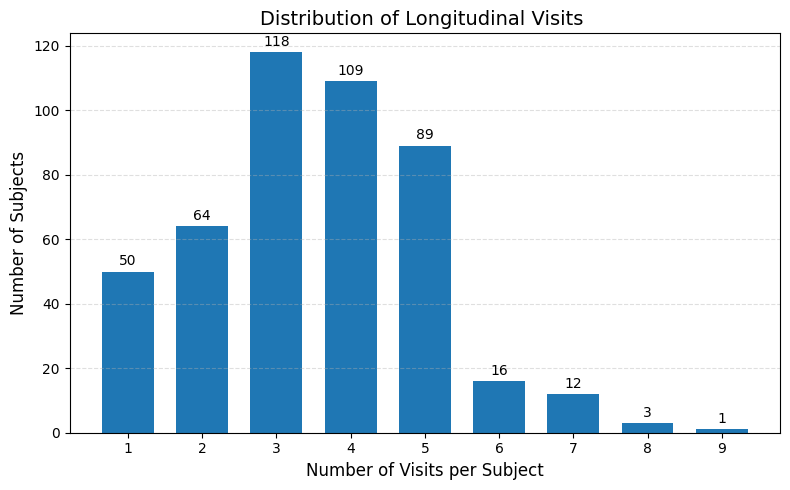

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(visit_dist.index, visit_dist.values, width=0.7)

plt.xlabel("Number of Visits per Subject", fontsize=12)
plt.ylabel("Number of Subjects", fontsize=12)
plt.title("Distribution of Longitudinal Visits ", fontsize=14)

plt.xticks(visit_dist.index)
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Add values above bars
for x, y in zip(visit_dist.index, visit_dist.values):
    plt.text(x, y + 2, str(y), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

In [31]:
# ── Save 3T-only metadata (4 classes) ────────────────────────────────────────
# This is the clean final CSV used downstream for splitting and feature extraction
out_path = "/home/enooo/Documents/Master/Early_Detection_AD/01_data/csv/master_metadata_3t.csv"

meta_final.to_csv(out_path, index=False)

print(f"Saved: {out_path}")
print(f"Shape: {meta_final.shape}")
print(meta_final['class'].value_counts())

Saved: /home/enooo/Documents/Master/Early_Detection_AD/01_data/csv/master_metadata_3t.csv
Shape: (1626, 23)
class
EMCI    658
CN      436
LMCI    294
AD      238
Name: count, dtype: int64


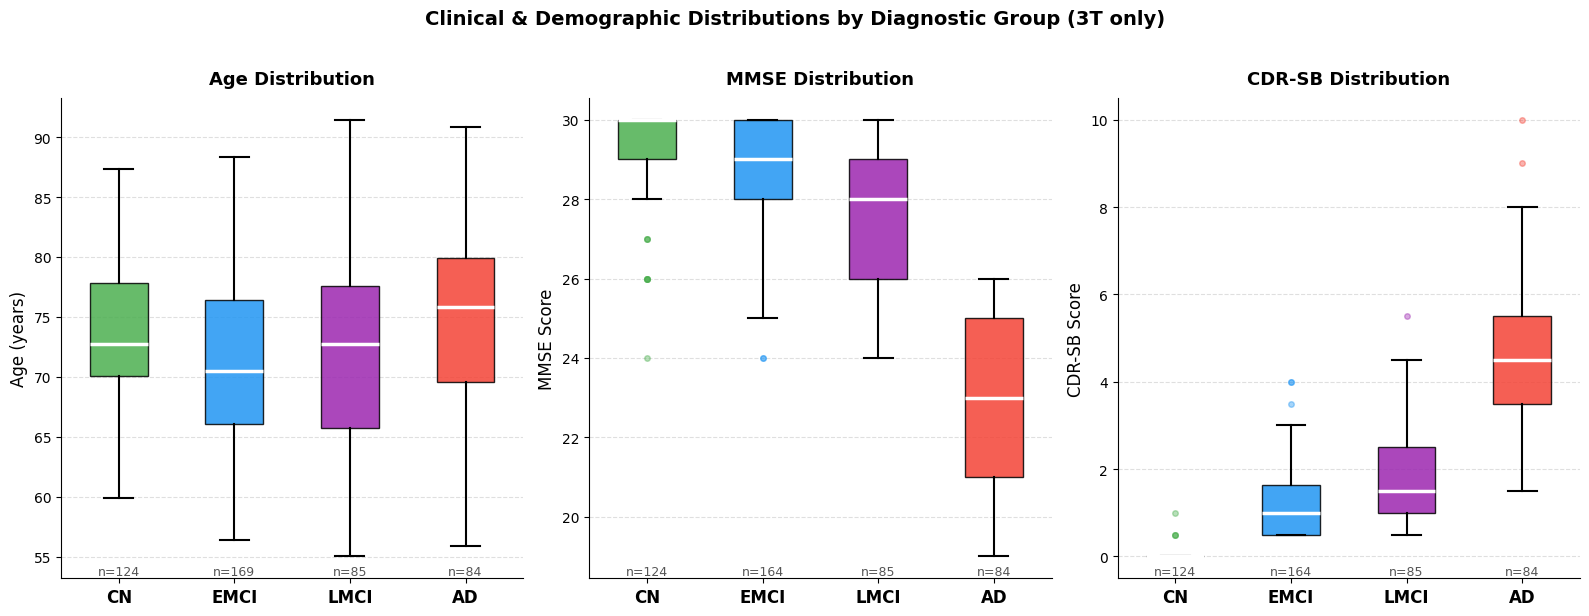

Saved -> eda_boxplots_3t.png


In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# class order and colors
CLASS_ORDER  = ['CN', 'EMCI', 'LMCI', 'AD']
CLASS_COLORS = {
    'CN'  : '#4CAF50',
    'EMCI': '#2196F3',
    'LMCI': '#9C27B0',
    'AD'  : '#F44336',
}

# one row per subject — from 3T-only, no-MCI dataset
subject_df = meta_final.drop_duplicates("subject_id").copy()
plot_df = subject_df[subject_df['class'].isin(CLASS_ORDER)].copy()
plot_df['class'] = pd.Categorical(plot_df['class'], categories=CLASS_ORDER, ordered=True)
plot_df = plot_df.sort_values('class')

data_by_class = [
    plot_df[plot_df['class'] == dx] for dx in CLASS_ORDER
]

def styled_boxplot(ax, series_list, labels, colors, ylabel, title):
    bp = ax.boxplot(
        [s.dropna().values for s in series_list],
        patch_artist=True,
        notch=False,
        widths=0.5,
        medianprops=dict(color='white', linewidth=2.5),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markersize=4, alpha=0.4),
    )
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
    for flier, color in zip(bp['fliers'], colors):
        flier.set_markerfacecolor(color)
        flier.set_markeredgecolor(color)

    ax.set_xticks(range(1, len(labels)+1))
    ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    for i, s in enumerate(series_list):
        ax.text(i+1, ax.get_ylim()[0], f'n={s.notna().sum()}',
                ha='center', va='bottom', fontsize=9, color='#555')

colors = [CLASS_COLORS[dx] for dx in CLASS_ORDER]

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Clinical & Demographic Distributions by Diagnostic Group (3T only)',
             fontsize=14, fontweight='bold', y=1.02)

styled_boxplot(
    axes[0],
    [d['age'] for d in data_by_class],
    CLASS_ORDER, colors,
    'Age (years)', 'Age Distribution'
)

styled_boxplot(
    axes[1],
    [d['MMSE_final'] for d in data_by_class],
    CLASS_ORDER, colors,
    'MMSE Score', 'MMSE Distribution'
)

styled_boxplot(
    axes[2],
    [d['CDRSB'] for d in data_by_class],
    CLASS_ORDER, colors,
    'CDR-SB Score', 'CDR-SB Distribution'
)

plt.tight_layout()
plt.savefig(
    '/home/enooo/Documents/Master/Early_Detection_AD/01_data/csv/eda_boxplots_3t.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Saved -> eda_boxplots_3t.png')

# EDA

In [33]:
df[
    [
        'subject_id',
        'PTGENDER_adni',
        'education',
        'MMSE_final',
        'CDRSB',
        'age'
    ]
].isna().sum()

subject_id       0
PTGENDER_adni    5
education        0
MMSE_final       5
CDRSB            5
age              0
dtype: int64

## 1. a subject-level summary table

In [34]:
import pandas as pd
import numpy as np

meta = pd.read_csv(
    "/home/enooo/Documents/Master/Early_Detection_AD/01_data/csv/master_metadata_clean.csv"
)

summary_rows = []

visit_df = meta.drop_duplicates(subset=['subject_id', 'image_id'])

for cls in sorted(meta["class"].unique()):

    d = meta[meta["class"] == cls].copy()

    n_subjects = d["subject_id"].nunique()
    n_visits   = len(d)

    males = (d.drop_duplicates("subject_id")["gender"] == 1).sum()
    females = (d.drop_duplicates("subject_id")["gender"] == 2).sum()

    age_mean = d.drop_duplicates("subject_id")["age"].mean()
    age_std  = d.drop_duplicates("subject_id")["age"].std()

    edu_mean = d.drop_duplicates("subject_id")["education"].mean()
    edu_std  = d.drop_duplicates("subject_id")["education"].std()

    mmse_mean = d["MMSE_final"].mean()
    mmse_std  = d["MMSE_final"].std()

    cdr_mean = d["CDRSB"].mean()
    cdr_std  = d["CDRSB"].std()

    mean_visits = n_visits / n_subjects

    summary_rows.append([
        cls,
        n_subjects,
        n_visits,
        f"{males}:{females}",
        f"{age_mean:.2f} ± {age_std:.2f}",
        f"{edu_mean:.2f} ± {edu_std:.2f}",
        f"{mmse_mean:.2f} ± {mmse_std:.2f}",
        f"{cdr_mean:.2f} ± {cdr_std:.2f}",
        round(mean_visits, 2)
    ])

summary = pd.DataFrame(
    summary_rows,
    columns=[
        "Class",
        "Subjects",
        "Visits",
        "M:F Ratio",
        "Age Mean±SD",
        "Education Mean±SD",
        "MMSE Mean±SD",
        "CDR-SB Mean±SD",
        "Mean Visits/Subject"
    ]
)

summary


,Class,Subjects,Visits,M:F Ratio,Age Mean±SD,Education Mean±SD,MMSE Mean±SD,CDR-SB Mean±SD,Mean Visits/Subject
0,AD,84,238,44:40,74.87 ± 8.07,15.61 ± 2.71,22.87 ± 1.99,4.44 ± 1.60,2.83
1,CN,124,436,62:62,73.81 ± 5.97,16.45 ± 2.80,29.27 ± 1.17,0.02 ± 0.12,3.52
2,EMCI,169,658,99:70,71.12 ± 7.33,16.08 ± 2.68,28.52 ± 1.41,1.24 ± 0.71,3.89
3,LMCI,85,294,37:48,72.29 ± 8.34,16.41 ± 2.55,27.47 ± 1.89,1.78 ± 1.06,3.46


## 2. MRI Protocol Summary

In [35]:
# Use clean_df (built from scans_df) so stats reflect only processed subjects,
# not every subject in the CSV files. This avoids a length mismatch when
# mri_acq_plane (or any other column) was missing from master_metadata_clean.csv
# because it wasn't included in keep_cols.
# Note: re-run the 'Save metadata' cell first if clean_df is not in memory.
src = clean_df.copy()

# Helper: return mode safely; falls back to 'N/A' if the column is all-NaN
def safe_mode(series):
    m = series.mode()
    return m[0] if len(m) > 0 else 'N/A'

protocol_summary = pd.DataFrame({
    "Feature": [
        "Manufacturer",
        "Scanner Model",
        "Field Strength",
        "Sequence",
        "TE",
        "TR",
        "TI",
        "Flip Angle",
        "Slice Thickness",
        "Orientation"
    ],
    "Value": [
        safe_mode(src["mri_mfr"]),
        safe_mode(src["mri_mfr_model"]),
        f"{safe_mode(src['mri_field_str'])} T",
        safe_mode(src["mri_sequence"]),
        f"{src['mri_te'].mean():.2f} ± {src['mri_te'].std():.2f}",
        f"{src['mri_tr'].mean():.0f} ± {src['mri_tr'].std():.0f}",
        f"{src['mri_ti'].mean():.0f} ± {src['mri_ti'].std():.0f}",
        f"{src['mri_flip_angle'].mean():.1f} ± {src['mri_flip_angle'].std():.1f}",
        f"{src['mri_thickness'].mean():.2f} mm",
        safe_mode(src["mri_acq_plane"])   # column now included in keep_cols
    ]
})

protocol_summary

,Feature,Value
0,Manufacturer,SIEMENS
1,Scanner Model,TrioTim
2,Field Strength,3.0 T
3,Sequence,GR/IR
4,TE,2.97 ± 0.03
5,TR,2221 ± 418
6,TI,900 ± 0
7,Flip Angle,9.0 ± 0.2
8,Slice Thickness,1.20 mm
9,Orientation,Sagittal


In [36]:
# ====================================
# Protocol summary table with correct
# values and percentages from clean_df
# ====================================

src = clean_df.copy()

# --- Field strength percentages ---
fs_counts   = src['mri_field_str'].value_counts()
fs_total    = fs_counts.sum()
fs_str      = " / ".join(
    f"{v} T ({fs_counts[v]/fs_total*100:.0f}%)"
    for v in sorted(fs_counts.index, reverse=True)  # 3.0 first
)

# --- Manufacturer percentages ---
mfr_counts  = src['mri_mfr'].value_counts()
mfr_total   = mfr_counts.sum()
mfr_str     = " / ".join(
    f"{k} ({v/mfr_total*100:.0f}%)"
    for k, v in mfr_counts.items()
)

# --- Build table ---
protocol_table = pd.DataFrame({
    "Parameter": [
        "Sequence",
        "Slice thickness",
        "TE / TR / TI",
        "Flip angle",
        "Field strength",
        "Manufacturer"
    ],
    "Value": [
        safe_mode(src['mri_sequence']),
        f"{src['mri_thickness'].median():.1f} mm",
        f"{src['mri_te'].median():.2f} / {src['mri_tr'].median():.0f} / {src['mri_ti'].median():.0f} ms",
        f"{src['mri_flip_angle'].median():.1f}°",
        fs_str,
        mfr_str
    ]
})

print(protocol_table.to_string(index=False))

      Parameter                                   Value
       Sequence                                   GR/IR
Slice thickness                                  1.2 mm
   TE / TR / TI                    2.98 / 2300 / 900 ms
     Flip angle                                    9.0°
 Field strength                            3.0 T (100%)
   Manufacturer SIEMENS (97%) / GE MEDICAL SYSTEMS (3%)


In [37]:
# ====================================
# Visits per subject
# ====================================

visits_per_subject = (
    df.groupby('subject_id')
      .agg(
          n_visits=('image_id', 'nunique'),
          class_=('class', 'first')
      )
      .reset_index()
)

# ====================================
# Overall distribution
# ====================================

overall = (
    visits_per_subject['n_visits']
    .value_counts()
    .sort_index()
)

print("=== Overall visit distribution ===")

for n_visits, n_subjects in overall.items():
    print(f"{n_subjects:4d} subjects have {n_visits} visit(s)")

print("\nSummary:")
print(f"Min  : {visits_per_subject['n_visits'].min()}")
print(f"Max  : {visits_per_subject['n_visits'].max()}")
print(
    f"Mean : {visits_per_subject['n_visits'].mean():.2f} ± "
    f"{visits_per_subject['n_visits'].std():.2f}"
)

=== Overall visit distribution ===
  50 subjects have 1 visit(s)
  64 subjects have 2 visit(s)
 118 subjects have 3 visit(s)
 109 subjects have 4 visit(s)
  89 subjects have 5 visit(s)
  16 subjects have 6 visit(s)
  12 subjects have 7 visit(s)
   3 subjects have 8 visit(s)
   1 subjects have 9 visit(s)

Summary:
Min  : 1
Max  : 9
Mean : 3.52 ± 1.51


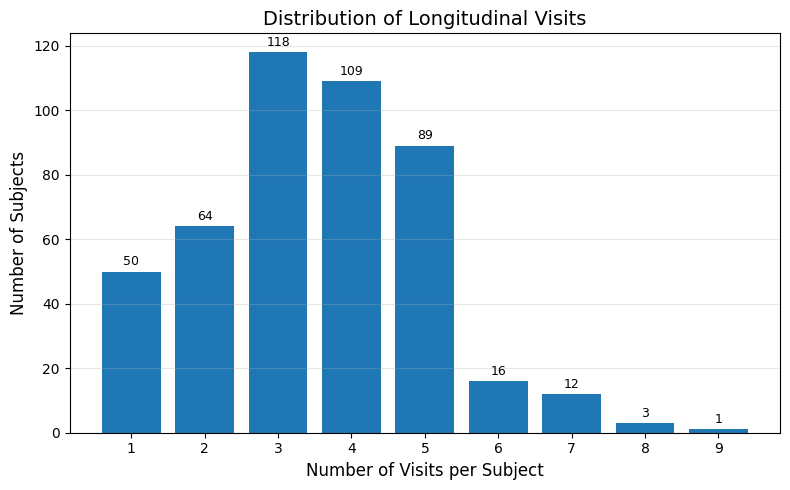

In [38]:
import matplotlib.pyplot as plt

# Distribution
overall = (
    visits_per_subject["n_visits"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))
plt.bar(overall.index, overall.values)

plt.xlabel("Number of Visits per Subject", fontsize=12)
plt.ylabel("Number of Subjects", fontsize=12)
plt.title("Distribution of Longitudinal Visits", fontsize=14)

plt.xticks(overall.index)
plt.grid(axis="y", alpha=0.3)

for x, y in zip(overall.index, overall.values):
    plt.text(x, y+2, str(y), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [39]:
import pandas as pd

SPLITS_DIR = '/home/enooo/Documents/Master/Early_Detection_AD/01_data/splits'


splits = {
    'Train': pd.read_csv(f'{SPLITS_DIR}/train_subjects.csv'),
    'Val'  : pd.read_csv(f'{SPLITS_DIR}/val_subjects.csv'),
    'Test' : pd.read_csv(f'{SPLITS_DIR}/test_subjects.csv'),
}

# visit_df should already exist from earlier cells (one row per subject+visit)
# it must contain: subject_id, class

CLASS_ORDER = ['AD', 'CN', 'EMCI', 'LMCI', 'MCI']

result = {}
for split_name, split_df in splits.items():
    subj_ids = set(split_df['subject_id'])
    v = visit_df[visit_df['subject_id'].isin(subj_ids)]
    result[split_name] = v['class'].value_counts()

visits_per_split = pd.DataFrame(result).reindex(CLASS_ORDER).fillna(0).astype(int)
visits_per_split.index.name = 'Class'

print("=== Visits per split ===")
print(visits_per_split)

# Optional: combine subject counts + visit counts side by side
subj_counts = {}
for split_name, split_df in splits.items():
    subj_counts[split_name] = split_df['class'].value_counts()

subjects_per_split = pd.DataFrame(subj_counts).reindex(CLASS_ORDER).fillna(0).astype(int)

combined = pd.concat(
    {'Subjects': subjects_per_split, 'Visits': visits_per_split},
    axis=1
)
print("\n=== Combined ===")
print(combined)

OUT = f'{SPLITS_DIR}/split_distribution_subjects_visits.csv'
combined.to_csv(OUT)
print(f'\nSaved -> {OUT}')

=== Visits per split ===
       Train  Val  Test
Class                  
AD       175   32    31
CN       298   67    71
EMCI     484   96    78
LMCI     211   41    42
MCI        0    0     0

=== Combined ===
     Subjects          Visits         
        Train Val Test  Train Val Test
AD         59  13   12    175  32   31
CN         87  18   19    298  67   71
EMCI      118  25   26    484  96   78
LMCI       59  13   13    211  41   42
MCI         0   0    0      0   0    0

Saved -> /home/enooo/Documents/Master/Early_Detection_AD/01_data/splits/split_distribution_subjects_visits.csv


In [40]:
meta.groupby("class")["subject_id"].nunique()

class
AD       84
CN      124
EMCI    169
LMCI     85
Name: subject_id, dtype: int64

In [41]:
visit_counts = (
    meta.groupby("subject_id")
        .size()
)

visit_counts.describe()

count    462.000000
mean       3.519481
std        1.510143
min        1.000000
25%        3.000000
50%        3.000000
75%        5.000000
max        9.000000
dtype: float64

In [42]:
pd.crosstab(
    meta["class"],
    meta["mri_mfr"]
)

mri_mfr,GE MEDICAL SYSTEMS,SIEMENS
class,,
AD,20,218
CN,36,400
EMCI,0,658
LMCI,0,294


In [43]:
pd.crosstab(
    meta["class"],
    meta["mri_field_str"]
)

mri_field_str,3.0
class,
AD,238
CN,436
EMCI,658
LMCI,294


In [45]:
total_files = len(list(processed_root.rglob("*.nii.gz")))
parsed_files = len(scans_df)

print(total_files, parsed_files)

3252 1626


In [46]:
mri_filtered = mri[
    mri.subject_id.isin(processed_subjects)
].copy()

mri_filtered["image_id"] = mri_filtered["image_id"].astype(str)

print("MRI rows after filtering:", len(mri_filtered))
print("Unique MRI image IDs:", mri_filtered.image_id.nunique())
mri_filtered.shape


MRI rows after filtering: 2100
Unique MRI image IDs: 2100


(2100, 23)

##  Identify the high-visit subjects and cross-check them against the conversion labels file

In [47]:
import pandas as pd

# ====================================
# 1. High-visit subjects (12+ visits)
# ====================================

high_visit = (
    visits_per_subject[visits_per_subject['n_visits'] >= 7]
    .sort_values('n_visits', ascending=False)
    .reset_index(drop=True)
)

print("=== Subjects with 12+ visits ===")
print(high_visit[['subject_id', 'class_', 'n_visits']].to_string(index=False))

# ====================================
# 2. Load conversion labels
# ====================================

csv_root = "/home/enooo/Documents/Master/Early_Detection_AD/01_data/csv"

conv = pd.read_csv(
    f"{csv_root}/clean_conversion_labels.csv"
)

meta = pd.read_csv(
    "/home/enooo/Documents/Master/Early_Detection_AD/01_data/csv/master_metadata_clean.csv"
)

# ====================================
# 3. EMCI and MCI subjects from df
# ====================================

# All EMCI subjects in your processed dataset
emci_subjects = set(df[df['class'] == 'EMCI']['subject_id'].unique())

# All MCI subjects in your processed dataset
mci_subjects  = set(df[df['class'] == 'MCI']['subject_id'].unique())

all_mci_emci  = emci_subjects | mci_subjects   # union

# ====================================
# 4. Cross-check against conversion file
# ====================================

# Keep only progressed (pEMCI / pMCI / pLMCI) rows
progressed = conv[conv['conversion_label'].str.startswith('p')]

# Which of your EMCI/MCI subjects appear as progressors?
emci_progressors = progressed[progressed['PTID'].isin(emci_subjects)].copy()
mci_progressors  = progressed[progressed['PTID'].isin(mci_subjects)].copy()

print("\n=== EMCI subjects that progressed (found in conversion file) ===")
print(f"Count: {emci_progressors['PTID'].nunique()}")
print(emci_progressors[['PTID', 'DX_bl', 'DX', 'months_diff', 'conversion_label']]
      .drop_duplicates('PTID').to_string(index=False))

print("\n=== MCI subjects that progressed (found in conversion file) ===")
print(f"Count: {mci_progressors['PTID'].nunique()}")
print(mci_progressors[['PTID', 'DX_bl', 'DX', 'months_diff', 'conversion_label']]
      .drop_duplicates('PTID').to_string(index=False))

# ====================================
# 5. Bonus: do any high-visit subjects also appear as progressors?
# ====================================

high_visit_ids = set(high_visit['subject_id'])
high_visit_progressors = progressed[progressed['PTID'].isin(high_visit_ids)]

print("\n=== High-visit subjects (12+) that also progressed ===")
if high_visit_progressors.empty:
    print("None found.")
else:
    print(high_visit_progressors[
        ['PTID', 'DX_bl', 'DX', 'months_diff', 'conversion_label']
    ].to_string(index=False))

=== Subjects with 12+ visits ===
subject_id class_  n_visits
035_S_2061   EMCI         9
005_S_0553     CN         8
005_S_0602     CN         8
037_S_0303     CN         8
014_S_2308   EMCI         7
022_S_2167   EMCI         7
032_S_2119   EMCI         7
009_S_2208   EMCI         7
035_S_2074   EMCI         7
036_S_2380   EMCI         7
072_S_2037   EMCI         7
072_S_2072   EMCI         7
072_S_2093   EMCI         7
072_S_2164   EMCI         7
073_S_2191   EMCI         7
123_S_2055   EMCI         7

=== EMCI subjects that progressed (found in conversion file) ===
Count: 7
      PTID DX_bl       DX  months_diff conversion_label
009_S_4958  EMCI Dementia     6.266667            pEMCI
009_S_4530  EMCI Dementia     6.300000            pEMCI
072_S_4102  EMCI Dementia    11.433333            pEMCI
011_S_2274  EMCI Dementia    12.366667            pEMCI
041_S_5026  EMCI Dementia    12.366667            pEMCI
057_S_2398  EMCI Dementia    12.533333            pEMCI
068_S_2316  EMCI Dementi

In [48]:
csv_root = "/home/enooo/Documents/Master/Early_Detection_AD/01_data/csv"

conv = pd.read_csv(
    f"{csv_root}/clean_conversion_labels.csv"
)

meta = pd.read_csv(
    "/home/enooo/Documents/Master/Early_Detection_AD/01_data/csv/master_metadata_clean.csv"
)

# ====================================
# Cross-compare meta labels vs conversion labels
# ====================================

# Get one row per subject from meta (class label assigned during dataset build)
meta_subjects = (
    meta[['subject_id', 'class']]
    .drop_duplicates('subject_id')
    .rename(columns={'class': 'meta_label'})
)

# Merge with conversion file on subject ID
merged = meta_subjects.merge(
    conv[['PTID', 'DX_bl', 'conversion_label']].drop_duplicates('PTID'),
    left_on='subject_id',
    right_on='PTID',
    how='inner'   # only subjects present in BOTH files
).drop(columns='PTID')

print(f"Subjects found in both files: {len(merged)}")
print()

# ====================================
# Summary: meta_label vs conversion_label
# ====================================

print("=== Label comparison (meta → conversion) ===")
print(merged.groupby(['meta_label', 'conversion_label']).size()
      .reset_index(name='count')
      .to_string(index=False))

print()

# ====================================
# Focus: MCI subjects in meta that are
# labeled differently in the conversion file
# ====================================

mci_in_meta = merged[merged['meta_label'] == 'MCI']

print(f"=== MCI subjects in meta found in conversion file: {len(mci_in_meta)} ===")
print(mci_in_meta[['subject_id', 'meta_label', 'DX_bl', 'conversion_label']]
      .to_string(index=False))

print()

# ====================================
# Focus: EMCI subjects in meta that progressed
# ====================================

emci_in_meta = merged[merged['meta_label'] == 'EMCI']

print(f"=== EMCI subjects in meta found in conversion file: {len(emci_in_meta)} ===")
print(emci_in_meta[['subject_id', 'meta_label', 'DX_bl', 'conversion_label']]
      .to_string(index=False))

Subjects found in both files: 26

=== Label comparison (meta → conversion) ===
meta_label conversion_label  count
      EMCI            pEMCI      7
      LMCI            pLMCI     19

=== MCI subjects in meta found in conversion file: 0 ===
Empty DataFrame
Columns: [subject_id, meta_label, DX_bl, conversion_label]
Index: []

=== EMCI subjects in meta found in conversion file: 7 ===
subject_id meta_label DX_bl conversion_label
011_S_2274       EMCI  EMCI            pEMCI
072_S_4102       EMCI  EMCI            pEMCI
009_S_4958       EMCI  EMCI            pEMCI
009_S_4530       EMCI  EMCI            pEMCI
068_S_2316       EMCI  EMCI            pEMCI
041_S_5026       EMCI  EMCI            pEMCI
057_S_2398       EMCI  EMCI            pEMCI


In [49]:
# ====================================
# Subjects whose DX_bl in conversion file
# is EMCI or LMCI but labeled MCI in meta
# ====================================

mci_in_meta = merged[merged['meta_label'] == 'MCI']

mci_was_lmci  = mci_in_meta[mci_in_meta['DX_bl'] == 'LMCI']
mci_was_emci  = mci_in_meta[mci_in_meta['DX_bl'] == 'EMCI']

# Split by original baseline diagnosis
mci_was_lmci = mci_was_lmci.merge(
    visits_per_subject[['subject_id', 'n_visits']],
    on='subject_id',
    how='left'
)

print(f"=== MCI in meta that were originally LMCI: {len(mci_was_lmci)} subjects ===")
print(mci_was_lmci[['subject_id', 'meta_label', 'DX_bl', 'conversion_label', 'n_visits']]
      .sort_values('n_visits', ascending=False)
      .to_string(index=False))


mci_was_emci = mci_was_emci.merge(
    visits_per_subject[['subject_id', 'n_visits']],
    on='subject_id',
    how='left'
)

print(f"=== MCI in meta that were originally EMCI: {len(mci_was_emci)} subjects ===")
print(mci_was_emci[['subject_id', 'meta_label', 'DX_bl', 'conversion_label', 'n_visits']]
      .sort_values('n_visits', ascending=False)
      .to_string(index=False))

=== MCI in meta that were originally LMCI: 0 subjects ===
Empty DataFrame
Columns: [subject_id, meta_label, DX_bl, conversion_label, n_visits]
Index: []
=== MCI in meta that were originally EMCI: 0 subjects ===
Empty DataFrame
Columns: [subject_id, meta_label, DX_bl, conversion_label, n_visits]
Index: []


In [50]:
# import nibabel as nib
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# import numpy as np

# # ====================================
# # Pick one pEMCI subject with most visits
# # e.g. 072_S_4102 — check how many visits they have
# # ====================================

# subject_id = "005_S_0324"   # change to any pEMCI subject

# # Get all scans for this subject in visit order
# subject_scans = (
#     meta[meta['subject_id'] == subject_id]
#     .sort_values('image_visit')   # visits in order: bl, m06, m12 ...
#     .reset_index(drop=True)
# )

# print(f"Subject: {subject_id}")
# print(f"Visits : {len(subject_scans)}")
# print(subject_scans[['image_visit', 'file_path']].to_string(index=False))

# # ====================================
# # Plot center axial slice for each visit
# # ====================================

# n_visits = len(subject_scans)
# fig, axes = plt.subplots(1, n_visits, figsize=(4 * n_visits, 4))

# if n_visits == 1:
#     axes = [axes]

# for i, (_, row) in enumerate(subject_scans.iterrows()):
#     img   = nib.load(row['file_path'])
#     data  = img.get_fdata()

#     # center axial slice (axis=2)
#     center = int(data.shape[2] // 2.2)
#     slice_ = np.float32(data[:, :, center].T)   # transpose for correct orientation

#     axes[i].imshow(slice_, cmap='gray', origin='lower')
#     axes[i].set_title(f"Visit: {row['image_visit']}", fontsize=10)
#     axes[i].axis('off')

# fig.suptitle(
#     f"Subject {subject_id} (pEMCI → Dementia)  |  Axial center slice across visits",
#     fontsize=13, fontweight='bold', y=1.02
# )
# plt.tight_layout()
# plt.show()

In [51]:
import pandas as pd
import shutil
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
SRC_ROOT  = Path("/home/enooo/Documents/Master/Early_Detection_AD/01_data/processed/classes")
DST_ROOT  = Path("/home/enooo/Documents/Master/Early_Detection_AD/01_data/processed/classes_3T")
META_PATH = Path("/home/enooo/Documents/Master/Early_Detection_AD/01_data/csv/master_metadata_3t.csv")

# ── Load 3T metadata (already filtered to 3T + 4 classes) ────────────────────
meta = pd.read_csv(META_PATH)

# Build a set of filenames that belong to 3T (e.g. "037_S_0552_I84216.nii.gz")
valid_files = set(Path(fp).name for fp in meta['file_path'])

print(f"3T scans to copy : {len(valid_files)}")

# ── Copy files ────────────────────────────────────────────────────────────────
copied  = 0
skipped = 0
missing = []

for class_dir in sorted(SRC_ROOT.iterdir()):
    if not class_dir.is_dir():
        continue

    # Skip MCI — not in our 4-class experiment
    if class_dir.name == 'MCI':
        print(f"Skipping class folder: MCI")
        continue

    dst_class = DST_ROOT / class_dir.name
    dst_class.mkdir(parents=True, exist_ok=True)

    for f in sorted(class_dir.glob("*.nii.gz")):
        if f.name in valid_files:
            dst = dst_class / f.name
            if dst.exists():
                skipped += 1          # already copied, skip to allow re-runs
            else:
                shutil.copy2(f, dst)
                copied += 1
        # files not in valid_files are 1.5T — silently ignore

print(f"\nDone.")
print(f"  Copied  : {copied}")
print(f"  Skipped (already exist): {skipped}")

# ── Sanity check: count files in dst ─────────────────────────────────────────
print("\nFiles per class in classes_3T:")
for class_dir in sorted(DST_ROOT.iterdir()):
    if class_dir.is_dir():
        n = len(list(class_dir.glob("*.nii.gz")))
        print(f"  {class_dir.name:6s} : {n}")

3T scans to copy : 1626

Done.
  Copied  : 0
  Skipped (already exist): 1626

Files per class in classes_3T:
  AD     : 238
  CN     : 436
  EMCI   : 658
  LMCI   : 294
  affine : 0


In [52]:
import pandas as pd
from pathlib import Path

META_PATH = "/home/enooo/Documents/Master/Early_Detection_AD/01_data/csv/master_metadata_3t.csv"

meta = pd.read_csv(META_PATH)

# Replace classes/ → classes_3T/ in all file paths — same filename, new folder
meta['file_path'] = meta['file_path'].str.replace(
    '/processed/classes/',
    '/processed/classes_3T/',
    regex=False
)

meta.to_csv(META_PATH, index=False)

print(f"Updated {len(meta)} rows in master_metadata_3t.csv")
print("Sample paths:")
print(meta['file_path'].head(3).to_string(index=False))

Updated 1626 rows in master_metadata_3t.csv
Sample paths:
/home/enooo/Documents/Master/Early_Detection_AD...
/home/enooo/Documents/Master/Early_Detection_AD...
/home/enooo/Documents/Master/Early_Detection_AD...


=== EMCI / LMCI Subject Count (before filtering) ===
class
EMCI    169
LMCI     85
Name: count, dtype: int64

Q3 (75th percentile) of entry age per class:
class
EMCI    76.41
LMCI    77.60
Name: entry_age, dtype: float64

=== After excluding subjects above Q3 ===
class
EMCI    127
LMCI     64
Name: count, dtype: int64

=== Scan counts after Q3 filter ===
class
EMCI    510
LMCI    229
Name: count, dtype: int64

=== Age summary after Q3 filter ===
       count   mean   std    min    25%    50%    75%    max
class                                                       
EMCI   127.0  67.88  5.08  56.41  63.82  68.29  71.82  76.41
LMCI    64.0  68.92  6.54  55.02  64.05  69.72  74.52  77.60



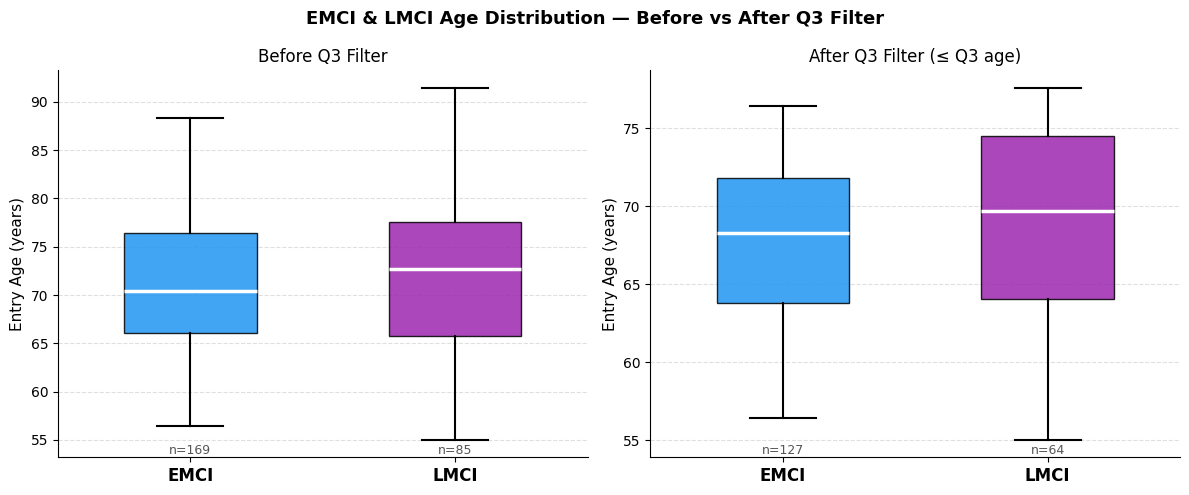

Saved -> emci_lmci_age_q3_filter.png
=== Visit interval summary (days) ===
count     799.0
mean      271.0
std       200.9
min        25.0
25%       118.0
50%       189.0
75%       368.0
max      1537.0
Name: gap_days, dtype: float64

Visits within 6-month window (±30 days): 180 / 799 (22.5%)

=== Irregular visit gaps (619 visits) ===
subject_id image_visit  gap_days  gap_months
123_S_4806         m03      25.0    0.821288
022_S_5004         m06      26.0    0.854139
035_S_2061         m06      59.0    1.938239
009_S_4903         m06      61.0    2.003942
082_S_5014         m06      62.0    2.036794
011_S_4366         m06      64.0    2.102497
141_S_2333         m06      66.0    2.168200
068_S_2248         m06      69.0    2.266754
014_S_4328         m06      70.0    2.299606
141_S_4423         m06      71.0    2.332457
032_S_2119         m03      71.0    2.332457
137_S_4303         m06      73.0    2.398160
023_S_2068         m03      75.0    2.463863
032_S_2247         m03      76.0 

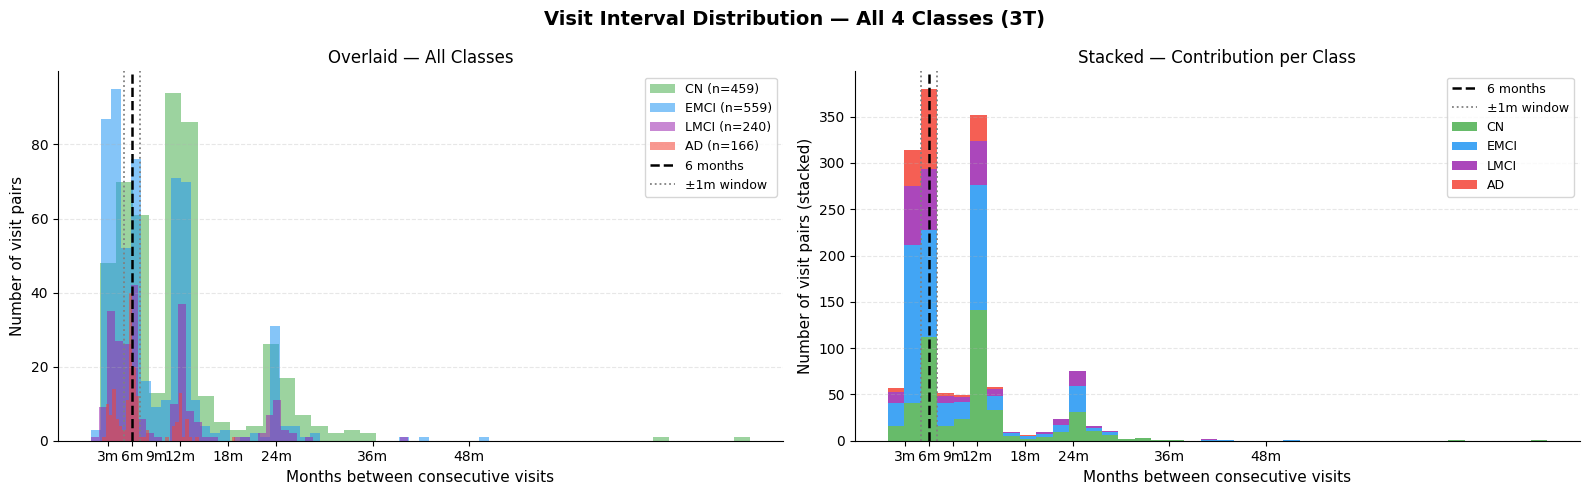

Saved -> all_classes_visit_intervals_combined.png


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

CSV_DIR = Path("/home/enooo/Documents/Master/Early_Detection_AD/01_data/csv")

# ── Load files ────────────────────────────────────────────────────────────────
meta    = pd.read_csv(CSV_DIR / "master_metadata_3t.csv")
study   = pd.read_csv(CSV_DIR / "ID_5548_Cohort_Analysis_Study_Entry_05Jun2026.csv")
manifest = pd.read_csv(CSV_DIR / "ID_5548_Cohort_Analysis_Manifest_05Jun2026.csv")

# ── Focus on EMCI and LMCI only ───────────────────────────────────────────────
mci_classes = ['EMCI', 'LMCI']
meta_mci = meta[meta['class'].isin(mci_classes)].copy()

# ── Get entry age for each subject ───────────────────────────────────────────
study_clean = study[['subject_id', 'entry_age']].drop_duplicates('subject_id')
meta_mci = meta_mci.merge(study_clean, on='subject_id', how='left')

# ── Subject-level DataFrame ───────────────────────────────────────────────────
subj_mci = meta_mci.drop_duplicates('subject_id')[['subject_id', 'class', 'entry_age']].copy()

print("=== EMCI / LMCI Subject Count (before filtering) ===")
print(subj_mci['class'].value_counts())
print()

# ── Q3 cutoff per class ───────────────────────────────────────────────────────
q3 = subj_mci.groupby('class')['entry_age'].quantile(0.75)
print("Q3 (75th percentile) of entry age per class:")
print(q3.round(2))
print()

# ── Filter: keep subjects AT or BELOW Q3 age ─────────────────────────────────
def below_q3(row):
    return row['entry_age'] <= q3[row['class']]

subj_filtered = subj_mci[subj_mci.apply(below_q3, axis=1)].copy()

print("=== After excluding subjects above Q3 ===")
print(subj_filtered['class'].value_counts())
print()

# ── How many scans remain ─────────────────────────────────────────────────────
valid_subjects = set(subj_filtered['subject_id'])
scans_filtered = meta_mci[meta_mci['subject_id'].isin(valid_subjects)]

print("=== Scan counts after Q3 filter ===")
print(scans_filtered['class'].value_counts())
print()

# ── Age distribution summary ──────────────────────────────────────────────────
print("=== Age summary after Q3 filter ===")
print(subj_filtered.groupby('class')['entry_age'].describe().round(2))
print()

# ── Boxplot: before vs after Q3 filter ───────────────────────────────────────
CLASS_COLORS = {'EMCI': '#2196F3', 'LMCI': '#9C27B0'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('EMCI & LMCI Age Distribution — Before vs After Q3 Filter',
             fontsize=13, fontweight='bold')

for ax, (df_plot, title) in zip(axes, [
    (subj_mci,      'Before Q3 Filter'),
    (subj_filtered, 'After Q3 Filter (≤ Q3 age)')
]):
    data   = [df_plot[df_plot['class'] == c]['entry_age'].dropna() for c in mci_classes]
    colors = [CLASS_COLORS[c] for c in mci_classes]

    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color='white', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markersize=4, alpha=0.4))

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
    for flier, color in zip(bp['fliers'], colors):
        flier.set_markerfacecolor(color)
        flier.set_markeredgecolor(color)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(mci_classes, fontsize=12, fontweight='bold')
    ax.set_ylabel('Entry Age (years)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    for i, s in enumerate(data):
        ax.text(i+1, ax.get_ylim()[0], f'n={len(s)}',
                ha='center', va='bottom', fontsize=9, color='#555')

plt.tight_layout()
plt.savefig(CSV_DIR / 'emci_lmci_age_q3_filter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> emci_lmci_age_q3_filter.png")


# ==========================================================
# Visit interval check — is each visit ~6 months apart?
# ==========================================================

# Get visit dates from manifest for EMCI/LMCI subjects only
manifest['image_id'] = manifest['image_id'].astype(str)
manifest['image_date'] = pd.to_datetime(manifest['image_date'])

mci_subject_ids = set(meta_mci['subject_id'])
manifest_mci = manifest[manifest['subject_id'].isin(mci_subject_ids)].copy()

# One row per subject+visit (drop duplicate series for same visit)
visits = (
    manifest_mci[['subject_id', 'image_visit', 'image_date']]
    .drop_duplicates(subset=['subject_id', 'image_visit'])
    .sort_values(['subject_id', 'image_date'])
)

# Compute gap between consecutive visits per subject (in days)
visits['prev_date'] = visits.groupby('subject_id')['image_date'].shift(1)
visits['gap_days']  = (visits['image_date'] - visits['prev_date']).dt.days
visits = visits.dropna(subset=['gap_days'])  # drop first visit (no gap)

print("=== Visit interval summary (days) ===")
print(visits['gap_days'].describe().round(1))
print()

# Flag visits deviating more than 30 days from 6 months (182 days)
visits['gap_months'] = visits['gap_days'] / 30.44
visits['expected_6m'] = visits['gap_days'].between(152, 212)  # 182 ± 30 days

print(f"Visits within 6-month window (±30 days): "
      f"{visits['expected_6m'].sum()} / {len(visits)} "
      f"({100*visits['expected_6m'].mean():.1f}%)")
print()

# Subjects with irregular intervals
irregular = visits[~visits['expected_6m']][['subject_id', 'image_visit', 'gap_days', 'gap_months']]
print(f"=== Irregular visit gaps ({len(irregular)} visits) ===")
print(irregular.sort_values('gap_days').to_string(index=False))

# ── Gap distribution plot (in months) — ALL 4 CLASSES ────────────────────────
manifest['image_id']   = manifest['image_id'].astype(str)
manifest['image_date'] = pd.to_datetime(manifest['image_date'])

# Use all 4 target classes
all_subject_ids = set(meta[meta['class'].isin(['CN', 'EMCI', 'LMCI', 'AD'])]['subject_id'])
manifest_all = manifest[manifest['subject_id'].isin(all_subject_ids)].copy()

# Merge class label
class_map = meta[['subject_id', 'class']].drop_duplicates('subject_id')
manifest_all = manifest_all.merge(class_map, on='subject_id', how='left')

# One row per subject+visit
visits_all = (
    manifest_all[['subject_id', 'class', 'image_visit', 'image_date']]
    .drop_duplicates(subset=['subject_id', 'image_visit'])
    .sort_values(['subject_id', 'image_date'])
)

# Compute gap between consecutive visits
visits_all['prev_date'] = visits_all.groupby('subject_id')['image_date'].shift(1)
visits_all['gap_days']  = (visits_all['image_date'] - visits_all['prev_date']).dt.days
visits_all = visits_all.dropna(subset=['gap_days'])
visits_all['gap_months'] = visits_all['gap_days'] / 30.44

# ── Plot: one histogram per class, overlaid ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Visit Interval Distribution — All 4 Classes (3T)',
             fontsize=14, fontweight='bold')

CLASS_ORDER  = ['CN', 'EMCI', 'LMCI', 'AD']
CLASS_COLORS = {'CN':'#4CAF50', 'EMCI':'#2196F3', 'LMCI':'#9C27B0', 'AD':'#F44336'}
MONTH_TICKS  = [3, 6, 9, 12, 18, 24, 36, 48]
MONTH_LABELS = ['3m','6m','9m','12m','18m','24m','36m','48m']

# ── Left: overlaid histogram ──────────────────────────────────────────────────
for cls in CLASS_ORDER:
    data = visits_all[visits_all['class'] == cls]['gap_months']
    axes[0].hist(data, bins=40, alpha=0.55,
                 label=f'{cls} (n={len(data)})',
                 color=CLASS_COLORS[cls], edgecolor='none')

for ax in axes:
    ax.axvline(6, color='black', linestyle='--', linewidth=1.8, label='6 months')
    ax.axvline(5, color='gray',  linestyle=':',  linewidth=1.3, label='±1m window')
    ax.axvline(7, color='gray',  linestyle=':',  linewidth=1.3)
    ax.set_xticks(MONTH_TICKS)
    ax.set_xticklabels(MONTH_LABELS)
    ax.set_xlabel('Months between consecutive visits', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

axes[0].set_ylabel('Number of visit pairs', fontsize=11)
axes[0].set_title('Overlaid — All Classes', fontsize=12)
axes[0].legend(fontsize=9)

# ── Right: stacked histogram ──────────────────────────────────────────────────
data_stacked = [
    visits_all[visits_all['class'] == cls]['gap_months'].dropna().values
    for cls in CLASS_ORDER
]
colors_list = [CLASS_COLORS[cls] for cls in CLASS_ORDER]

axes[1].hist(data_stacked, bins=40, stacked=True,
             alpha=0.85, label=CLASS_ORDER,
             color=colors_list, edgecolor='none')

axes[1].set_ylabel('Number of visit pairs (stacked)', fontsize=11)
axes[1].set_title('Stacked — Contribution per Class', fontsize=12)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(CSV_DIR / 'all_classes_visit_intervals_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> all_classes_visit_intervals_combined.png")

- the distribution has clear peaks around ~90 days (3m), ~150–180 days (6m), and ~365–400 days (12m) 

In [8]:
print("=" * 65)
print("VISIT INTERVAL STATISTICS — ALL 4 CLASSES (3T)")
print("=" * 65)

# Define interval buckets matching ADNI protocol cadences
bins      = [0,   60,  90,  152, 212, 365, 400, 730, 9999]
bin_labels = ['<2m', '~3m', '<6m', '~6m', '6m–12m', '~12m', '12m–24m', '>24m']

visits_all['interval_bucket'] = pd.cut(
    visits_all['gap_days'],
    bins=bins,
    labels=bin_labels,
    right=True
)

print("\n── Per-class interval summary (months) ──────────────────────")
for cls in CLASS_ORDER:
    d = visits_all[visits_all['class'] == cls]['gap_months']
    print(f"\n{cls} (n={len(d)} visit pairs):")
    print(f"  Mean  : {d.mean():.1f} months")
    print(f"  Median: {d.median():.1f} months")
    print(f"  Std   : {d.std():.1f} months")
    print(f"  Range : {d.min():.1f} – {d.max():.1f} months")

print("\n── Interval bucket distribution (% of visit pairs) ──────────")
bucket_table = (
    visits_all.groupby(['class', 'interval_bucket'], observed=True)
    .size()
    .unstack(fill_value=0)
)
# Show as percentages
bucket_pct = bucket_table.div(bucket_table.sum(axis=1), axis=0).mul(100).round(1)
print(bucket_pct.to_string())

print("\n── 6-month compliance (152–212 days) ────────────────────────")
for cls in CLASS_ORDER:
    d = visits_all[visits_all['class'] == cls]
    within = d['gap_days'].between(152, 212).sum()
    total  = len(d)
    print(f"  {cls:5s}: {within:3d} / {total:3d}  ({100*within/total:.1f}%)")

print("\n── 3-month compliance (75–105 days) ─────────────────────────")
for cls in CLASS_ORDER:
    d = visits_all[visits_all['class'] == cls]
    within = d['gap_days'].between(75, 105).sum()
    total  = len(d)
    print(f"  {cls:5s}: {within:3d} / {total:3d}  ({100*within/total:.1f}%)")

print("\n── Key insight ───────────────────────────────────────────────")
overall_median = visits_all['gap_months'].median()
print(f"  Overall median interval : {overall_median:.1f} months")
print(f"  ADNI-1 (CN/AD) typically follows 6/12/24m cadence")
print(f"  ADNI-2 (EMCI/LMCI) typically follows 3/6/12m cadence")
print(f"  High std ({visits_all['gap_months'].std():.1f}m) reflects mixed protocols across phases")

VISIT INTERVAL STATISTICS — ALL 4 CLASSES (3T)


NameError: name 'visits_all' is not defined

In [9]:
import pandas as pd
import numpy as np
from pathlib import Path

CSV_DIR = Path("/home/enooo/Documents/Master/Early_Detection_AD/01_data/csv")

meta     = pd.read_csv(CSV_DIR / "master_metadata_3t.csv")
manifest = pd.read_csv(CSV_DIR / "ID_5548_Cohort_Analysis_Manifest_05Jun2026.csv")
study    = pd.read_csv(CSV_DIR / "ID_5548_Cohort_Analysis_Study_Entry_05Jun2026.csv")

TARGET_CLASSES = ['CN', 'EMCI', 'LMCI', 'AD']
CLASS_LABEL    = {'CN': 'NC', 'EMCI': 'EMCI', 'LMCI': 'LMCI', 'AD': 'AD'}

    
# ── Prepare manifest ──────────────────────────────────────────────────────────
manifest['image_id']   = manifest['image_id'].astype(str)
manifest['image_date'] = pd.to_datetime(manifest['image_date'])
meta['image_id']       = meta['image_id'].astype(str)

# ── Keep only 3T subjects in our 4 classes ────────────────────────────────────
valid_subjects = meta[meta['class'].isin(TARGET_CLASSES)][['subject_id','class']].drop_duplicates('subject_id')

# Check how many EMCI/LMCI subjects actually appear in the manifest
for cls in TARGET_CLASSES:
    subj_cls = valid_subjects[valid_subjects['class'] == cls]['subject_id']
    in_manifest = manifest['subject_id'].isin(subj_cls).sum()
    print(f"{cls}: {len(subj_cls)} subjects in meta, {in_manifest} rows found in manifest")

manifest_f = manifest[manifest['subject_id'].isin(valid_subjects['subject_id'])].copy()
manifest_f = manifest_f.merge(valid_subjects, on='subject_id', how='left')

# ── One row per subject+visit (drop duplicate series) ────────────────────────
visits = (
    manifest_f[['subject_id', 'class', 'image_visit', 'image_date']]
    .drop_duplicates(subset=['subject_id', 'image_visit'])
    .sort_values(['subject_id', 'image_date'])
    .reset_index(drop=True)
)

# ── Compute months from baseline (bl) per subject ────────────────────────────
# ── Compute months from baseline per subject ──────────────────────────────────
# ADNI-1 (CN, AD) uses 'bl' as baseline visit code
# ADNI-2/3 (EMCI, LMCI) uses 'scmri' (screening MRI) as the first visit
# → take whichever comes first chronologically as the baseline

baseline = (
    visits
    .sort_values('image_date')
    .groupby('subject_id')
    .first()                          # earliest visit = baseline
    .reset_index()[['subject_id', 'image_date']]
    .rename(columns={'image_date': 'baseline_date'})
)

visits = visits.merge(baseline, on='subject_id', how='left')
visits['months_from_bl'] = (
    (visits['image_date'] - visits['baseline_date']).dt.days / 30.44
)

# ── Rank visits per subject (0 = baseline/first, 1 = second visit, ...) ───────
# exclude the first visit (rank 0) since months_from_bl = 0 there
visits['visit_rank'] = (
    visits.sort_values('image_date')
    .groupby('subject_id')
    .cumcount()                       # 0-indexed: 0=first, 1=second, ...
)

non_bl = visits[visits['visit_rank'] > 0].copy()  # drop the first visit
non_bl['visit_rank'] = non_bl['visit_rank']        # keep as 1,2,3...

# ── Demographics ──────────────────────────────────────────────────────────────
study_clean = study[['subject_id', 'entry_age']].drop_duplicates('subject_id')

# Gender from meta (1=M, 2=F)
gender = meta[['subject_id','gender']].drop_duplicates('subject_id')

subj_info = (
    valid_subjects
    .merge(study_clean, on='subject_id', how='left')
    .merge(gender,      on='subject_id', how='left')
)

# ── Build the summary table ───────────────────────────────────────────────────
# Find max visit rank across all classes
max_visit = int(non_bl['visit_rank'].max())

rows = []

for cls in TARGET_CLASSES:
    subj_cls   = subj_info[subj_info['class'] == cls]
    n          = len(subj_cls)
    age_m      = subj_cls['entry_age'].mean()
    age_s      = subj_cls['entry_age'].std()
    n_male     = (subj_cls['gender'] == 1).sum()
    n_female   = (subj_cls['gender'] == 2).sum()

    row = {
        'Study Group'      : CLASS_LABEL[cls],
        'N Subjects'       : n,
        'Age (mean ± std)' : f"{age_m:.2f} ± {age_s:.2f}",
        'Sex (M/F)'        : f"{n_male}/{n_female}",
    }

    # Visit duration columns
    non_bl_cls = non_bl[non_bl['class'] == cls]

    for v in range(1, max_visit + 1):
        v_data = non_bl_cls[non_bl_cls['visit_rank'] == v]['months_from_bl'].dropna()
        if len(v_data) >= 3:   # only show if at least 3 subjects have this visit
            row[f'Visit {v} (months from BL)'] = f"{v_data.mean():.2f} ± {v_data.std():.2f}  (n={len(v_data)})"
        else:
            row[f'Visit {v} (months from BL)'] = '—'

    rows.append(row)

qc_table = pd.DataFrame(rows)

# ── Print ─────────────────────────────────────────────────────────────────────
print("=== Quality Check Table ===\n")
print(qc_table.to_string(index=False))

# ── Save ──────────────────────────────────────────────────────────────────────
qc_table.to_csv(CSV_DIR / "qc_visit_table.csv", index=False)
print("\nSaved -> qc_visit_table.csv")

CN: 124 subjects in meta, 697 rows found in manifest
EMCI: 169 subjects in meta, 735 rows found in manifest
LMCI: 85 subjects in meta, 331 rows found in manifest
AD: 84 subjects in meta, 337 rows found in manifest
=== Quality Check Table ===

Study Group  N Subjects Age (mean ± std) Sex (M/F) Visit 1 (months from BL) Visit 2 (months from BL) Visit 3 (months from BL) Visit 4 (months from BL) Visit 5 (months from BL) Visit 6 (months from BL) Visit 7 (months from BL) Visit 8 (months from BL) Visit 9 (months from BL) Visit 10 (months from BL)
         NC         124     73.81 ± 5.97     62/62     5.92 ± 4.80  (n=113)    13.45 ± 6.67  (n=107)     25.43 ± 7.03  (n=87)    45.56 ± 11.30  (n=66)    59.58 ± 15.04  (n=30)    73.37 ± 12.66  (n=23)    85.63 ± 11.97  (n=16)    93.96 ± 10.54  (n=11)    107.19 ± 13.26  (n=4)                         —
       EMCI         169     71.12 ± 7.33     99/70     4.17 ± 3.48  (n=155)     9.45 ± 4.00  (n=146)    18.43 ± 5.18  (n=116)     34.14 ± 9.98  (n=83)   

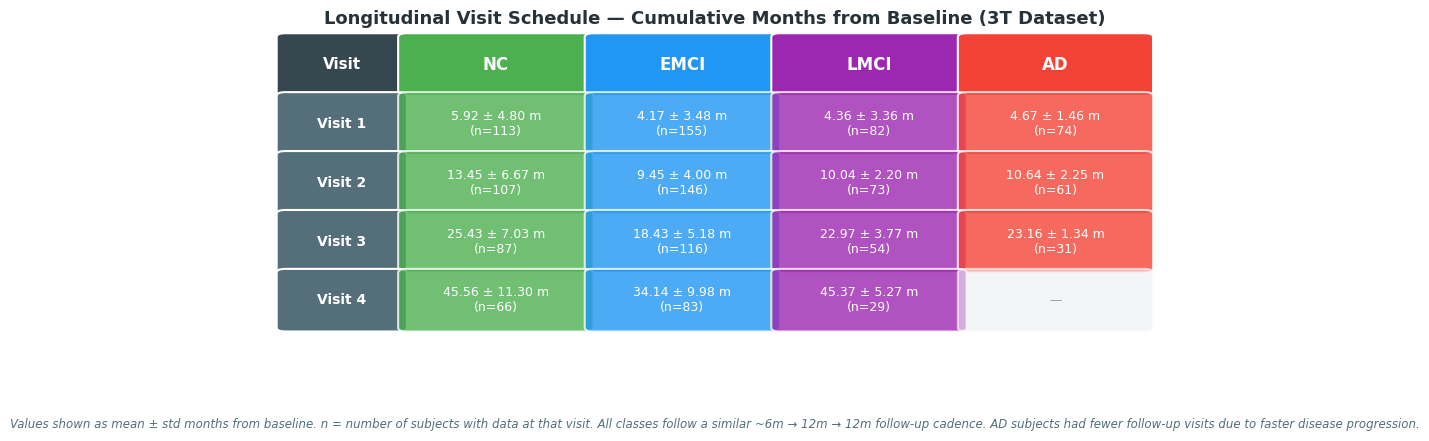

Saved -> visit_schedule_table.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data ─────────────────────────────────────────────────────────────────────
visits = ['Visit 1', 'Visit 2', 'Visit 3', 'Visit 4']
classes = ['NC', 'EMCI', 'LMCI', 'AD']

# Mean ± std from your table (mean only for display, n in parentheses)
data = {
    'NC':   [('5.92', '4.80', 113), ('13.45', '6.67', 107), ('25.43', '7.03', 87),  ('45.56', '11.30', 66)],
    'EMCI': [('4.17', '3.48', 155), ('9.45',  '4.00', 146), ('18.43', '5.18', 116), ('34.14', '9.98',  83)],
    'LMCI': [('4.36', '3.36', 82),  ('10.04', '2.20', 73),  ('22.97', '3.77', 54),  ('45.37', '5.27',  29)],
    'AD':   [('4.67', '1.46', 74),  ('10.64', '2.25', 61),  ('23.16', '1.34', 31),  ('—',     '—',     0)],
}

CLASS_COLORS = {
    'NC'  : '#4CAF50',
    'EMCI': '#2196F3',
    'LMCI': '#9C27B0',
    'AD'  : '#F44336',
}

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.axis('off')

# Column headers: Visit + 4 classes
col_labels = [''] + classes
n_cols = len(col_labels)
n_rows = len(visits) + 1  # header + 4 visit rows

# Table layout
col_widths = [0.14] + [0.215] * 4   # visit label col + 4 class cols
row_height = 0.16
x_starts = np.cumsum([0] + col_widths[:-1])
y_starts = [1.0 - i * row_height for i in range(n_rows)]

def draw_cell(ax, x, y, w, h, text, facecolor, textcolor='white',
              fontsize=11, bold=False, alpha=1.0):
    rect = mpatches.FancyBboxPatch(
        (x + 0.005, y - h + 0.005), w - 0.010, h - 0.010,
        boxstyle="round,pad=0.01",
        facecolor=facecolor, edgecolor='white', linewidth=1.5,
        transform=ax.transAxes, clip_on=False, alpha=alpha
    )
    ax.add_patch(rect)
    ax.text(x + w/2, y - h/2, text,
            ha='center', va='center', fontsize=fontsize,
            color=textcolor, fontweight='bold' if bold else 'normal',
            transform=ax.transAxes)

# ── Header row ────────────────────────────────────────────────────────────────
# Empty top-left cell
draw_cell(ax, x_starts[0], y_starts[0], col_widths[0], row_height,
          'Visit', '#37474F', fontsize=11, bold=True)

for j, cls in enumerate(classes):
    draw_cell(ax, x_starts[j+1], y_starts[0], col_widths[j+1], row_height,
              cls, CLASS_COLORS[cls], fontsize=12, bold=True)

# ── Data rows ─────────────────────────────────────────────────────────────────
for i, visit in enumerate(visits):
    row_y = y_starts[i + 1]

    # Visit label cell
    draw_cell(ax, x_starts[0], row_y, col_widths[0], row_height,
              visit, '#546E7A', fontsize=10, bold=True)

    # Class data cells
    for j, cls in enumerate(classes):
        mean, std, n = data[cls][i]
        if mean == '—':
            cell_text = '—'
            face = '#ECEFF1'
            tcolor = '#9E9E9E'
            alpha = 0.6
        else:
            cell_text = f"{mean} ± {std} m\n(n={n})"
            face = CLASS_COLORS[cls]
            tcolor = 'white'
            alpha = 0.80

        draw_cell(ax, x_starts[j+1], row_y, col_widths[j+1], row_height,
                  cell_text, face, textcolor=tcolor,
                  fontsize=9, bold=False, alpha=alpha)

# ── Title & footnote ──────────────────────────────────────────────────────────
ax.text(0.5, 1.02,
        'Longitudinal Visit Schedule — Cumulative Months from Baseline (3T Dataset)',
        ha='center', va='bottom', fontsize=13, fontweight='bold',
        color='#263238', transform=ax.transAxes)

ax.text(0.5, -0.04,
        'Values shown as mean ± std months from baseline. '
        'n = number of subjects with data at that visit. '
        'All classes follow a similar ~6m → 12m → 12m follow-up cadence. '
        'AD subjects had fewer follow-up visits due to faster disease progression.',
        ha='center', va='top', fontsize=8.5, color='#546E7A',
        transform=ax.transAxes, style='italic')

plt.tight_layout()
plt.savefig(CSV_DIR / 'visit_schedule_table.png',
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved -> visit_schedule_table.png")

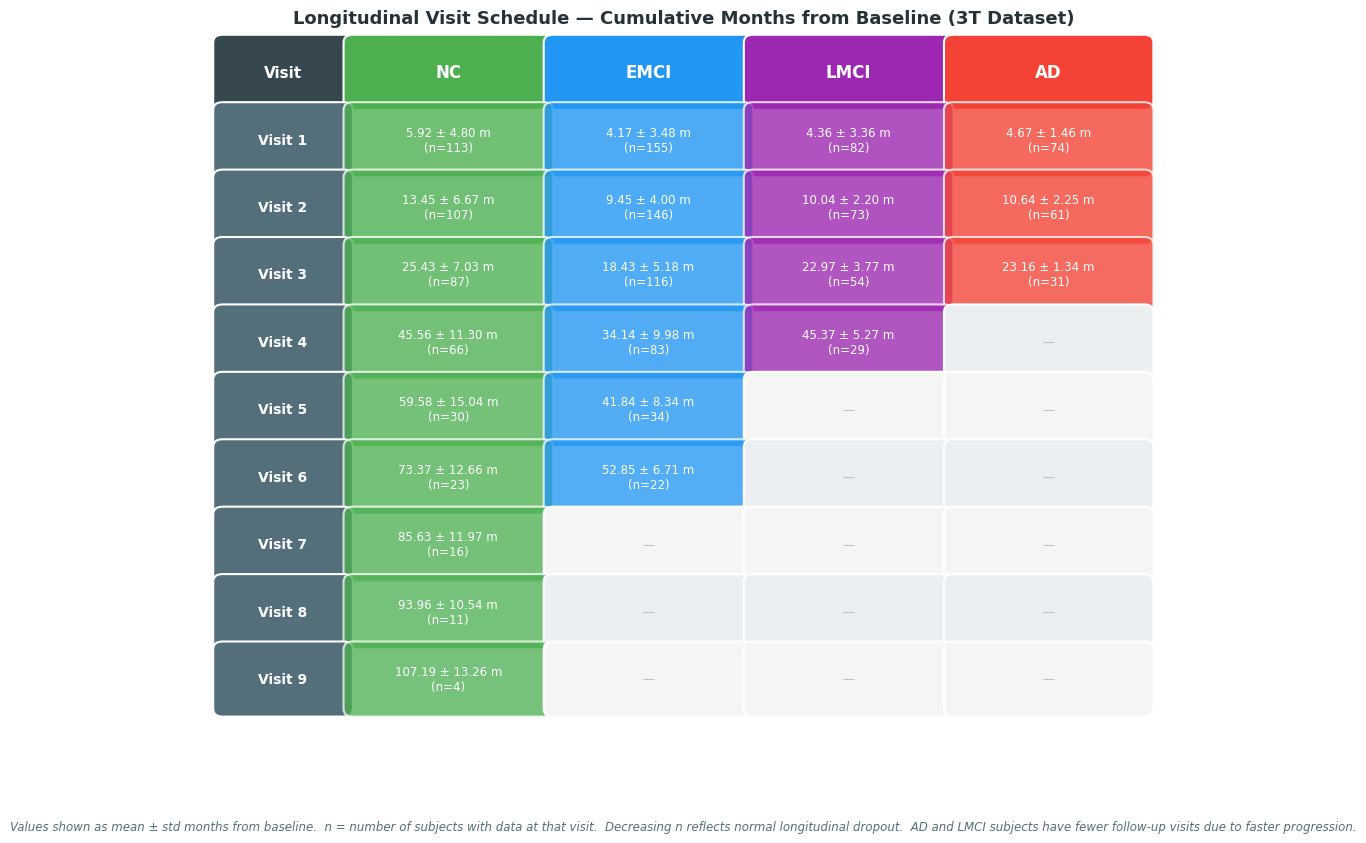

Saved -> visit_schedule_table.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data (all visits from your table) ────────────────────────────────────────
visits = ['Visit 1', 'Visit 2', 'Visit 3', 'Visit 4',
          'Visit 5', 'Visit 6', 'Visit 7', 'Visit 8', 'Visit 9']

classes = ['NC', 'EMCI', 'LMCI', 'AD']

data = {
    'NC':   [
        ('5.92',  '4.80',  113), ('13.45', '6.67',  107), ('25.43', '7.03',   87),
        ('45.56', '11.30',  66), ('59.58', '15.04',  30), ('73.37', '12.66',  23),
        ('85.63', '11.97',  16), ('93.96', '10.54',  11), ('107.19','13.26',   4),
    ],
    'EMCI': [
        ('4.17',  '3.48',  155), ('9.45',  '4.00',  146), ('18.43', '5.18',  116),
        ('34.14', '9.98',   83), ('41.84', '8.34',   34), ('52.85', '6.71',   22),
        ('—',     '—',       0), ('—',     '—',       0), ('—',     '—',       0),
    ],
    'LMCI': [
        ('4.36',  '3.36',   82), ('10.04', '2.20',   73), ('22.97', '3.77',   54),
        ('45.37', '5.27',   29), ('—',     '—',       0), ('—',     '—',       0),
        ('—',     '—',       0), ('—',     '—',       0), ('—',     '—',       0),
    ],
    'AD':   [
        ('4.67',  '1.46',   74), ('10.64', '2.25',   61), ('23.16', '1.34',   31),
        ('—',     '—',       0), ('—',     '—',       0), ('—',     '—',       0),
        ('—',     '—',       0), ('—',     '—',       0), ('—',     '—',       0),
    ],
}

CLASS_COLORS = {
    'NC'  : '#4CAF50',
    'EMCI': '#2196F3',
    'LMCI': '#9C27B0',
    'AD'  : '#F44336',
}

# ── Figure — taller to fit 9 visit rows ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 8.5))
ax.axis('off')

col_widths = [0.14] + [0.215] * 4
row_height = 0.088
x_starts   = np.cumsum([0] + col_widths[:-1])
n_rows     = len(visits) + 1
y_starts   = [1.0 - i * row_height for i in range(n_rows)]

def draw_cell(ax, x, y, w, h, text, facecolor, textcolor='white',
              fontsize=10, bold=False, alpha=1.0):
    rect = mpatches.FancyBboxPatch(
        (x + 0.005, y - h + 0.005), w - 0.010, h - 0.010,
        boxstyle="round,pad=0.01",
        facecolor=facecolor, edgecolor='white', linewidth=1.5,
        transform=ax.transAxes, clip_on=False, alpha=alpha
    )
    ax.add_patch(rect)
    ax.text(x + w/2, y - h/2, text,
            ha='center', va='center', fontsize=fontsize,
            color=textcolor, fontweight='bold' if bold else 'normal',
            transform=ax.transAxes)

# ── Header row ────────────────────────────────────────────────────────────────
draw_cell(ax, x_starts[0], y_starts[0], col_widths[0], row_height,
          'Visit', '#37474F', fontsize=11, bold=True)

for j, cls in enumerate(classes):
    draw_cell(ax, x_starts[j+1], y_starts[0], col_widths[j+1], row_height,
              cls, CLASS_COLORS[cls], fontsize=12, bold=True)

# ── Data rows ─────────────────────────────────────────────────────────────────
for i, visit in enumerate(visits):
    row_y = y_starts[i + 1]

    # Alternate row background for readability
    bg = '#F5F5F5' if i % 2 == 0 else '#ECEFF1'

    draw_cell(ax, x_starts[0], row_y, col_widths[0], row_height,
              visit, '#546E7A', fontsize=10, bold=True)

    for j, cls in enumerate(classes):
        mean, std, n = data[cls][i]
        if mean == '—':
            cell_text = '—'
            face      = bg
            tcolor    = '#BDBDBD'
            alpha     = 1.0
        else:
            cell_text = f"{mean} ± {std} m\n(n={n})"
            face      = CLASS_COLORS[cls]
            tcolor    = 'white'
            alpha     = 0.75 + 0.05 * (1 - i / len(visits))  # slightly fade later visits

        draw_cell(ax, x_starts[j+1], row_y, col_widths[j+1], row_height,
                  cell_text, face, textcolor=tcolor,
                  fontsize=8.5, bold=False, alpha=alpha)

# ── Title & footnote ──────────────────────────────────────────────────────────
ax.text(0.5, 1.015,
        'Longitudinal Visit Schedule — Cumulative Months from Baseline (3T Dataset)',
        ha='center', va='bottom', fontsize=13, fontweight='bold',
        color='#263238', transform=ax.transAxes)

ax.text(0.5, -0.02,
        'Values shown as mean ± std months from baseline.  '
        'n = number of subjects with data at that visit.  '
        'Decreasing n reflects normal longitudinal dropout.  '
        'AD and LMCI subjects have fewer follow-up visits due to faster progression.',
        ha='center', va='top', fontsize=8.5, color='#546E7A',
        transform=ax.transAxes, style='italic')

plt.tight_layout()
plt.savefig(CSV_DIR / 'visit_schedule_table.png',
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved -> visit_schedule_table.png")

In [13]:
import pandas as pd
from pathlib import Path

CSV_DIR  = Path("/home/enooo/Documents/Master/Early_Detection_AD/01_data/csv")
manifest = pd.read_csv(CSV_DIR / "ID_5548_Cohort_Analysis_Manifest_05Jun2026.csv")
meta     = pd.read_csv(CSV_DIR / "master_metadata_affine_3t.csv")

manifest['image_date'] = pd.to_datetime(manifest['image_date'])
manifest['image_id']   = manifest['image_id'].astype(str)
meta['image_id']       = meta['image_id'].astype(str)

# Keep only subjects in our 4-class 3T dataset
valid_subjects = set(meta['subject_id'])
manifest_f = manifest[manifest['subject_id'].isin(valid_subjects)].copy()

# One row per subject + visit (drop duplicate series)
visits = (
    manifest_f[['subject_id', 'image_visit', 'image_date']]
    .drop_duplicates(subset=['subject_id', 'image_visit'])
    .sort_values(['subject_id', 'image_date'])
    .reset_index(drop=True)
)

# Exclude screening visit from interval calculation
# scmri is administrative — not a follow-up interval
visits = visits[visits['image_visit'] != 'scmri'].copy()

# Compute interval between EACH consecutive visit pair per subject
visits['prev_date']  = visits.groupby('subject_id')['image_date'].shift(1)
visits['prev_visit'] = visits.groupby('subject_id')['image_visit'].shift(1)
visits['gap_days']   = (visits['image_date'] - visits['prev_date']).dt.days
visits['gap_months'] = visits['gap_days'] / 30.44

# Drop first visit per subject (no previous visit to compare)
intervals = visits.dropna(subset=['gap_days']).copy()

# Label each interval pair clearly
intervals['interval_label'] = (
    intervals['prev_visit'] + ' → ' + intervals['image_visit']
)

print("=== Per-subject interval statistics (months) ===")
print(intervals['gap_months'].describe().round(2))

print("\n=== Most common visit transitions ===")
print(intervals['interval_label'].value_counts().head(15))

print("\n=== Mean interval per subject (months) ===")
per_subject = (
    intervals.groupby('subject_id')['gap_months']
    .agg(['mean','std','min','max','count'])
    .round(2)
)
print(per_subject.describe().round(2))

# Save full interval table
intervals.to_csv(CSV_DIR / "visit_intervals_per_subject.csv", index=False)
per_subject.to_csv(CSV_DIR / "visit_intervals_summary.csv")
print("\nSaved both CSVs.")

=== Per-subject interval statistics (months) ===
count    1361.00
mean        9.81
std         7.09
min         0.82
25%         5.29
50%         6.73
75%        12.22
max        83.15
Name: gap_months, dtype: float64

=== Most common visit transitions ===
interval_label
m06 → m12     374
m03 → m06     311
m12 → m24     282
m24 → m48      95
m24 → m36      72
bl → m06       53
m36 → m48      42
m48 → m60      17
m60 → m72      15
m72 → m84      14
m03 → m12      13
m12 → m36      10
m84 → m96      10
m36 → m60       9
m96 → m108      6
Name: count, dtype: int64

=== Mean interval per subject (months) ===
         mean     std     min     max   count
count  421.00  383.00  421.00  421.00  421.00
mean     9.14    5.52    4.77   15.29    3.23
std      4.29    3.89    3.68    9.19    1.52
min      2.33    0.07    0.82    2.33    1.00
25%      6.41    3.01    3.22    8.51    2.00
50%      8.20    4.41    3.78   12.42    3.00
75%     11.44    8.64    5.29   23.59    4.00
max     40.14   36.7

In [ ]:
Environment:
  OS           : Ubuntu 22.04 (WSL2)
  IDE          : VS Code (main) + Jupyter (analysis/EDA)
  Language     : Python 3.10+

Core libraries:
  Data         : pandas, numpy
  Neuroimaging : nibabel, nilearn, FSL (command line)
  Image proc.  : scikit-image (GLCM, LBP), Pillow
  ML classical : scikit-learn (SVM, RF, PCA, metrics)
  ML deep      : PyTorch + torchvision (CNN, ResNet)
  Quantum      : PennyLane (VQC, QCNN)
  Plotting     : matplotlib, seaborn
  Atlas/ROI:   : FSL (Juelich atlas), nibabel

File formats:
  MRI volumes  : .nii.gz (NIfTI)
  Metadata     : .csv
  Models       : .pt (PyTorch), .pkl (sklearn)

Version control:
  Git + GitHub (recommended if not already)